# CatBoost — Búsqueda de Hiperparámetros con Optuna (L1, L2, L3)

**Objetivo:** mejorar el CatBoost baseline (AUROC L1=0.8316, L2=0.8775, L3=0.8941) mediante búsqueda bayesiana de hiperparámetros.
**Features:** idénticas al notebook 02 (vitales + acuity + n_medications + chiefcomplaint categórica)
**Estrategia:** Optuna con `TPESampler`; trials cortos (500 iter + early_stop=30) para exploración rápida; reentrenamiento final con 2000 iteraciones y los mejores parámetros.

**Tiempo estimado:** 60-90 min (N_TRIALS=30 por target). Reducir a N_TRIALS=20 si el tiempo es limitado.

## 1. Setup y librerías

Importaciones y configuración de logging. `optuna.logging.WARNING` suprime el output verboso de cada trial; `logging.getLogger("catboost")` hace lo mismo para CatBoost.

In [1]:
import os
import json
import logging
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from dotenv import load_dotenv

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.getLogger("catboost").setLevel(logging.WARNING)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

N_TRIALS   = 30
TARGETS    = ["L1", "L2", "L3"]
TARGET_NAMES = {
    "L1": "Ingreso hospitalario",
    "L2": "Resultado crítico en urgencias",
    "L3": "Intervención crítica en urgencias",
}
RANDOM_SEED = 42
TASK_TYPE   = "CPU"

print(f"Optuna {optuna.__version__} — N_TRIALS={N_TRIALS} por target")
print(f"CatBoost task_type: {TASK_TYPE}")

Optuna 4.8.0 — N_TRIALS=30 por target
CatBoost task_type: CPU


## 2. Carga de datos y preprocesamiento

Se cargan las particiones temporales y se construyen las matrices de features con el mismo procedimiento que en `02_catboost_model.ipynb` para garantizar comparabilidad.

In [2]:
load_dotenv(dotenv_path=Path("../../.env"), override=True)
if not os.getenv("MIMIC_IV_ED_PATH"):
    load_dotenv(dotenv_path=Path(".env"), override=True)

DATA          = Path(os.getenv("MIMIC_IV_ED_PATH", ""))
PROCESSED_DIR = Path("../../data/processed")

print(f"DATA         : {DATA}  |  existe: {DATA.exists()}")
print(f"PROCESSED_DIR: {PROCESSED_DIR.resolve()}")

df_train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
df_val   = pd.read_parquet(PROCESSED_DIR / "val.parquet")
print(f"\nTrain: {df_train.shape[0]:,} × {df_train.shape[1]}  |  Val: {df_val.shape[0]:,} × {df_val.shape[1]}")

DATA         : C:\Users\cuent\Documents\UAX\TFM\TFM\CodigoGit\data  |  existe: True
PROCESSED_DIR: C:\Users\cuent\Documents\UAX\TFM\TFM\CodigoGit\data\processed

Train: 278,320 × 21  |  Val: 59,640 × 21


In [3]:
# Agregación de n_medications desde medrecon
print("Cargando medrecon...")
df_medrecon = pd.read_csv(DATA / "medrecon.csv", low_memory=False)
n_meds = df_medrecon.groupby("stay_id").size().rename("n_medications").reset_index()

df_train = df_train.merge(n_meds, on="stay_id", how="left")
df_val   = df_val.merge(n_meds, on="stay_id", how="left")
df_train["n_medications"] = df_train["n_medications"].fillna(0).astype(int)
df_val["n_medications"]   = df_val["n_medications"].fillna(0).astype(int)

# pain se almacena como str en los parquets; CatBoost requiere float en features numéricas
df_train["pain"] = pd.to_numeric(df_train["pain"], errors="coerce")
df_val["pain"]   = pd.to_numeric(df_val["pain"],   errors="coerce")

# Normalización de features categóricas para CatBoost
for df in [df_train, df_val]:
    df["chiefcomplaint"]    = df["chiefcomplaint"].fillna("").astype(str).str.lower().str.strip()
    df["arrival_transport"] = df["arrival_transport"].fillna("desconocido").astype(str).str.lower().str.strip()

NUMERIC_FEATURES = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp", "acuity", "n_medications", "pain"]
CAT_FEATURES     = ["chiefcomplaint", "arrival_transport"]
ALL_FEATURES     = NUMERIC_FEATURES + CAT_FEATURES
CAT_INDICES      = [ALL_FEATURES.index(f) for f in CAT_FEATURES]

X_train = df_train[ALL_FEATURES].copy()
X_val   = df_val[ALL_FEATURES].copy()

print(f"Features: {len(ALL_FEATURES)} ({len(NUMERIC_FEATURES)} numéricas + {len(CAT_FEATURES)} categóricas, índices {CAT_INDICES})")
print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}")

Cargando medrecon...
Features: 11 (9 numéricas + 2 categóricas, índices [9, 10])
X_train: (278320, 11)  |  X_val: (59640, 11)


## 3. Función objetivo de Optuna

Cada trial entrena un CatBoost con parámetros propuestos (máx. 500 iter + early_stop=30) y devuelve el AUROC en validación.

| Parámetro | CPU | GPU | Tipo |
|-----------|-----|-----|------|
| `learning_rate` | [0.01, 0.3] | [0.01, 0.3] | log-uniform |
| `depth` | [4, **10**] | [4, **8**] | int (GPU max=8) |
| `l2_leaf_reg` | [1, 10] | [1, 10] | int |
| `bagging_temperature` | [0, 5] | [0, 5] | float |
| `random_strength` | [1e-9, 10] | [1e-9, 10] | log-uniform |
| `min_data_in_leaf` | ✅ [5, 100] | ❌ omitido | sólo SymmetricTree CPU |
| `rsm` | [0.5, 1.0] | [0.5, 1.0] | float (equiv. colsample_bylevel) |

**Nota GPU:** `depth>8` y `min_data_in_leaf` no están soportados con `task_type="GPU"` + `grow_policy="SymmetricTree"` (defecto). El espacio se adapta automáticamente según `TASK_TYPE`.

In [4]:
def make_objective(X_tr, y_tr, X_v, y_v, cat_indices, pos_weight):
    """Devuelve una función objetivo cerrada con los datos del target dado."""
    def objective(trial):
        # depth máximo 8 en GPU (limitación CatBoost SymmetricTree)
        max_depth = 8 if TASK_TYPE == "GPU" else 10

        params = {
            "iterations":          500,
            "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "depth":               trial.suggest_int("depth", 4, max_depth),
            "l2_leaf_reg":         trial.suggest_int("l2_leaf_reg", 1, 10),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
            "random_strength":     trial.suggest_float("random_strength", 1e-9, 10.0, log=True),
            "scale_pos_weight":    pos_weight,
            "eval_metric":         "AUC",
            "cat_features":        cat_indices,
            "task_type":           TASK_TYPE,
            "random_seed":         RANDOM_SEED,
            "verbose":             0,
            "early_stopping_rounds": 30,
        }
        # rsm y min_data_in_leaf no soportados en GPU con SymmetricTree
        if TASK_TYPE == "CPU":
            params["rsm"]              = trial.suggest_float("rsm", 0.5, 1.0)
            params["min_data_in_leaf"] = trial.suggest_int("min_data_in_leaf", 5, 100)

        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_v, y_v))
        y_pred = model.predict_proba(X_v)[:, 1]
        return roc_auc_score(y_v, y_pred)
    return objective

## 4. Optimización por target (L1, L2, L3)

Se ejecuta la búsqueda bayesiana de forma independiente para cada target. El `scale_pos_weight` se recalcula en cada iteración a partir de la prevalencia del target correspondiente.

In [5]:
best_params  = {}
best_aurocs  = {}

for target in TARGETS:
    y_tr = df_train[target]
    y_v  = df_val[target]
    pos_weight = (len(y_tr) - y_tr.sum()) / y_tr.sum()

    print(f"\n{'='*65}")
    print(f"Optimizando TARGET: {target} — {TARGET_NAMES[target]}")
    print(f"Prevalencia train: {y_tr.mean()*100:.2f}%  |  scale_pos_weight: {pos_weight:.2f}")
    print(f"{'='*65}")

    sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
    study = optuna.create_study(
        direction="maximize",
        study_name=f"catboost_{target}",
        sampler=sampler,
    )
    objective = make_objective(X_train, y_tr, X_val, y_v, CAT_INDICES, pos_weight)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_params[target]  = study.best_params
    best_aurocs[target]  = study.best_value

    print(f"\n{target} — Mejor AUROC (Optuna, trials cortos): {study.best_value:.4f}")
    print(f"   Mejores parámetros: {study.best_params}")

print("\nBúsqueda completada para todos los targets.")


Optimizando TARGET: L1 — Ingreso hospitalario
Prevalencia train: 38.55%  |  scale_pos_weight: 1.59


  0%|          | 0/30 [00:00<?, ?it/s]


L1 — Mejor AUROC (Optuna, trials cortos): 0.8410
   Mejores parámetros: {'learning_rate': 0.0895903437346317, 'depth': 7, 'l2_leaf_reg': 9, 'bagging_temperature': 4.114094890831893, 'random_strength': 9.105208298152147e-08, 'rsm': 0.6954256428896507, 'min_data_in_leaf': 18}

Optimizando TARGET: L2 — Resultado crítico en urgencias
Prevalencia train: 1.54%  |  scale_pos_weight: 63.79


  0%|          | 0/30 [00:00<?, ?it/s]


L2 — Mejor AUROC (Optuna, trials cortos): 0.8928
   Mejores parámetros: {'learning_rate': 0.07477274499016055, 'depth': 4, 'l2_leaf_reg': 10, 'bagging_temperature': 0.09106449032118703, 'random_strength': 0.0009893793716016558, 'rsm': 0.8897141011558393, 'min_data_in_leaf': 81}

Optimizando TARGET: L3 — Intervención crítica en urgencias
Prevalencia train: 0.56%  |  scale_pos_weight: 177.07


  0%|          | 0/30 [00:00<?, ?it/s]


L3 — Mejor AUROC (Optuna, trials cortos): 0.9014
   Mejores parámetros: {'learning_rate': 0.08686422687376032, 'depth': 4, 'l2_leaf_reg': 10, 'bagging_temperature': 1.5635950743272535, 'random_strength': 1.1962754787618616e-09, 'rsm': 0.8727602775103626, 'min_data_in_leaf': 80}

Búsqueda completada para todos los targets.


## 5. Resumen de mejores parámetros por target

Tabla con los hiperparámetros seleccionados por Optuna y el AUROC alcanzado en los trials de exploración (máx. 500 iteraciones). Las columnas `depth` y `min_data_in_leaf` reflejan las preferencias del sampler bayesiano para cada distribución de clases.

In [6]:
print("=== Mejores hiperparámetros por target ===\n")
df_best = pd.DataFrame(best_params).T
df_best.index.name = "Target"
df_best["AUROC_optuna"] = pd.Series(best_aurocs)
print(df_best.round(5).to_string())

=== Mejores hiperparámetros por target ===

        learning_rate  depth  l2_leaf_reg  bagging_temperature  random_strength      rsm  min_data_in_leaf  AUROC_optuna
Target                                                                                                                  
L1            0.08959    7.0          9.0              4.11409          0.00000  0.69543              18.0       0.84098
L2            0.07477    4.0         10.0              0.09106          0.00099  0.88971              81.0       0.89284
L3            0.08686    4.0         10.0              1.56360          0.00000  0.87276              80.0       0.90137


## 6. Reentrenamiento final con mejores parámetros

Los trials de búsqueda usaron máximo 500 iteraciones para reducir el tiempo de exploración. El reentrenamiento final usa 2000 iteraciones con early_stop=50 para obtener el rendimiento real del modelo optimizado.

In [7]:
final_models  = {}
final_results = {}

for target in TARGETS:
    y_tr = df_train[target]
    y_v  = df_val[target]
    pos_weight = (len(y_tr) - y_tr.sum()) / y_tr.sum()

    params = best_params[target].copy()
    params.update({
        "iterations":            2000,
        "scale_pos_weight":      pos_weight,
        "eval_metric":           "AUC",
        "cat_features":          CAT_INDICES,
        "task_type":             TASK_TYPE,
        "random_seed":           RANDOM_SEED,
        "verbose":               100,
        "early_stopping_rounds": 50,
    })

    print(f"\n{'='*65}")
    print(f"REENTRENANDO: {target} — {TARGET_NAMES[target]}")
    print(f"{'='*65}")

    model = CatBoostClassifier(**params)
    model.fit(X_train, y_tr, eval_set=(X_val, y_v))

    y_pred = model.predict_proba(X_val)[:, 1]
    auroc  = roc_auc_score(y_v, y_pred)
    auprc  = average_precision_score(y_v, y_pred)
    brier  = brier_score_loss(y_v, y_pred)

    print(f"\nAUROC : {auroc:.4f}")
    print(f"AUPRC : {auprc:.4f}  (azar: {y_v.mean():.4f})")
    print(f"Brier : {brier:.4f}")

    final_results[target] = {"AUROC": auroc, "AUPRC": auprc, "Brier": brier, "Prev_val": float(y_v.mean())}
    final_models[target]  = model

print("\nReentrenamiento completado para L1, L2 y L3.")


REENTRENANDO: L1 — Ingreso hospitalario
0:	test: 0.7763809	best: 0.7763809 (0)	total: 248ms	remaining: 8m 16s
100:	test: 0.8381160	best: 0.8381160 (100)	total: 20.3s	remaining: 6m 21s
200:	test: 0.8397029	best: 0.8397029 (200)	total: 40.6s	remaining: 6m 3s
300:	test: 0.8405061	best: 0.8405061 (300)	total: 1m	remaining: 5m 44s
400:	test: 0.8407670	best: 0.8407717 (394)	total: 1m 21s	remaining: 5m 26s
500:	test: 0.8409189	best: 0.8409797 (466)	total: 1m 42s	remaining: 5m 7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.840979664
bestIteration = 466

Shrink model to first 467 iterations.

AUROC : 0.8410
AUPRC : 0.7650  (azar: 0.3831)
Brier : 0.1637

REENTRENANDO: L2 — Resultado crítico en urgencias
0:	test: 0.8281003	best: 0.8281003 (0)	total: 160ms	remaining: 5m 19s
100:	test: 0.8881118	best: 0.8881118 (100)	total: 15.2s	remaining: 4m 46s
200:	test: 0.8917009	best: 0.8917123 (197)	total: 30.6s	remaining: 4m 34s
300:	test: 0.8925823	best: 0.8926881 (283)	total: 46.3

## 7. Resumen de resultados Optuna

Métricas del modelo CatBoost optimizado en validación. Las comparativas entre arquitecturas (LogReg, CatBoost, LSTM, TabTransformer, NAM) se realizan en el notebook de evaluación con el test set.

In [8]:
rows = []
for target in TARGETS:
    o = final_results[target]
    rows.append({
        'Target':   target,
        'Nombre':   TARGET_NAMES[target],
        'AUROC':    o['AUROC'],
        'AUPRC':    o['AUPRC'],
        'Brier':    o['Brier'],
        'Prev_val': o['Prev_val'],
    })
df_summary = pd.DataFrame(rows).set_index('Target')
print('=== CatBoost + Optuna — Resultados en validación ===')
print(df_summary.round(4).to_string())

=== CatBoost + Optuna — Resultados en validación ===
                                   Nombre   AUROC   AUPRC   Brier  Prev_val
Target                                                                     
L1                   Ingreso hospitalario  0.8410  0.7650  0.1637    0.3831
L2         Resultado crítico en urgencias  0.8928  0.2392  0.1250    0.0147
L3      Intervención crítica en urgencias  0.9014  0.1135  0.1046    0.0061


## 8. Feature importance de los modelos optimizados

Importancia de permutación nativa de CatBoost para los modelos reentrenados con los hiperparámetros óptimos. Permite comparar si la selección bayesiana altera el ranking de variables respecto al baseline.

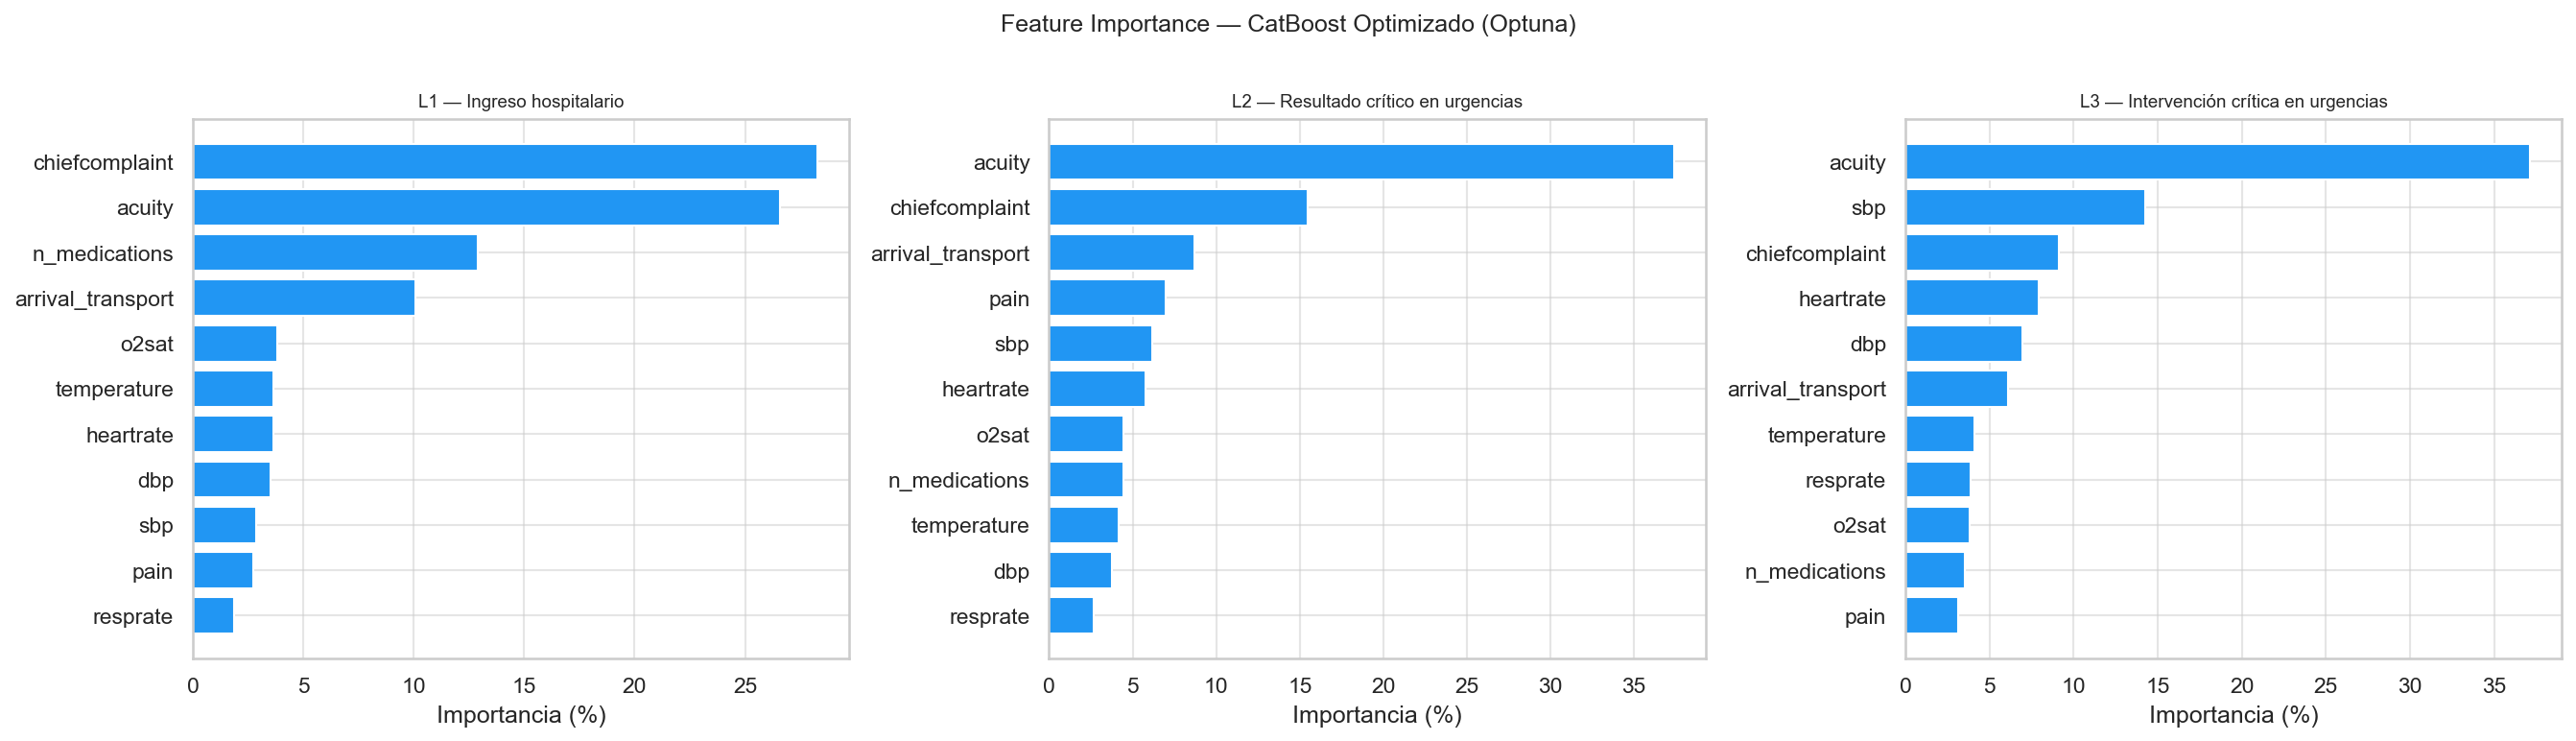

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes, TARGETS):
    importances = final_models[target].get_feature_importance()
    df_imp = (
        pd.DataFrame({"feature": ALL_FEATURES, "importance": importances})
        .sort_values("importance", ascending=True)
    )
    ax.barh(df_imp["feature"], df_imp["importance"], color="#2196F3")
    ax.set_title(f"{target} — {TARGET_NAMES[target]}", fontsize=9)
    ax.set_xlabel("Importancia (%)")

plt.suptitle("Feature Importance — CatBoost Optimizado (Optuna)", y=1.02)
plt.tight_layout()
plt.show()

## 9. Guardado de modelos y parámetros

Se persisten los modelos CatBoost (`.cbm`), los hiperparámetros óptimos y las métricas finales en el directorio `models/catboost_optuna/<timestamp>/` para su uso en la fase de evaluación.

In [10]:
TIMESTAMP  = datetime.now().strftime("%Y%m%d_%H%M%S")
MODELS_DIR = Path("../../models/catboost_optuna") / TIMESTAMP
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Guardar modelos CatBoost
for target, model in final_models.items():
    save_path = MODELS_DIR / f"catboost_{target}.cbm"
    model.save_model(str(save_path))
    print(f"Guardado: {save_path}")

# Guardar mejores parámetros y resultados
with open(MODELS_DIR / "best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

with open(MODELS_DIR / "final_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

print(f"\nArtefactos guardados en: {MODELS_DIR}")
print("  best_params.json — hiperparámetros óptimos por target")
print("  final_results.json — AUROC/AUPRC/Brier finales")
for target in TARGETS:
    print(f"  catboost_{target}.cbm — modelo serializado")

Guardado: ..\..\models\catboost_optuna\20260609_224204\catboost_L1.cbm
Guardado: ..\..\models\catboost_optuna\20260609_224204\catboost_L2.cbm
Guardado: ..\..\models\catboost_optuna\20260609_224204\catboost_L3.cbm

Artefactos guardados en: ..\..\models\catboost_optuna\20260609_224204
  best_params.json — hiperparámetros óptimos por target
  final_results.json — AUROC/AUPRC/Brier finales
  catboost_L1.cbm — modelo serializado
  catboost_L2.cbm — modelo serializado
  catboost_L3.cbm — modelo serializado
